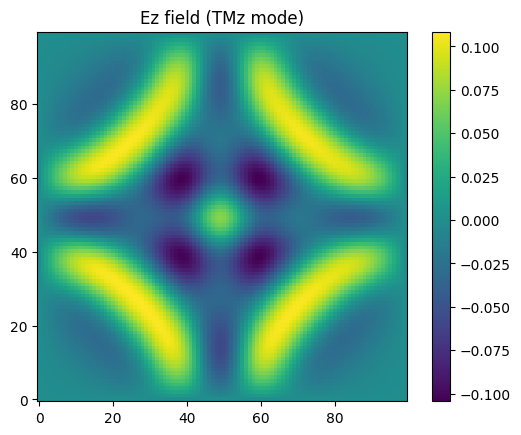

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Physical parameters (vacuum)
eps = 1.0
mu = 1.0
c = 1 / np.sqrt(eps * mu)

# Grid
Nx, Ny = 100, 100
dx = dy = 1e-2

# CFL condition (2D)
dt = 0.5 / (c * np.sqrt((1/dx**2) + (1/dy**2)))

Nt = 300

# Fields
Ez = np.zeros((Nt, Nx, Ny))
Hx = np.zeros((Nt, Nx, Ny))
Hy = np.zeros((Nt, Nx, Ny))

# Initial condition: Gaussian pulse
x = np.arange(Nx)
y = np.arange(Ny)
X, Y = np.meshgrid(x, y, indexing='ij')

Ez[0] = np.exp(-((X-50)**2 + (Y-50)**2) / 100)

# Time stepping
for n in range(Nt-1):

    # --- Update Hx ---
    for i in range(Nx):
        for j in range(Ny-1):
            Hx[n+1, i, j] = Hx[n, i, j] - (dt/(mu*dy)) * (Ez[n, i, j+1] - Ez[n, i, j])

    # --- Update Hy ---
    for i in range(Nx-1):
        for j in range(Ny):
            Hy[n+1, i, j] = Hy[n, i, j] + (dt/(mu*dx)) * (Ez[n, i+1, j] - Ez[n, i, j])

    # --- Update Ez ---
    for i in range(1, Nx-1):
        for j in range(1, Ny-1):
            Ez[n+1, i, j] = Ez[n, i, j] + (dt/eps) * (
                (Hy[n+1, i, j] - Hy[n+1, i-1, j]) / dx
                - (Hx[n+1, i, j] - Hx[n+1, i, j-1]) / dy
            )

    # Simple PEC boundary (Ez = 0)
    Ez[n+1, 0, :] = 0
    Ez[n+1, -1, :] = 0
    Ez[n+1, :, 0] = 0
    Ez[n+1, :, -1] = 0

# ---- Visualization ----

plt.imshow(Ez[-1], origin='lower')
plt.title("Ez field (TMz mode)")
plt.colorbar()
plt.show()